In [7]:
import numpy as np
import pandas as pd
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
import os

In [13]:
os.getcwd()

'/media/daten/pirku/masters_thesis/MasterThesis/recombination_rate_inference/scripts'

In [71]:
def load_file(file_name: str) -> pd.DataFrame:
    try:
        return pd.read_csv(file_name, header=0, sep="\t")
    except Exception as e:
        print(f"Error: reading {file_name}: {e}")
        return pd.DataFrame()
hyperparameters: pd.DataFrame = load_file("../lists/blackcap_n100_hyperparam.txt")
hyperparameters[hyperparameters.columns[:4]]

,Block_Penalty,Window_Size,Pearson_Corr_1bp,Pearson_Corr_10kb
0,10.0,25.0,0.939575,0.529393
1,10.0,30.0,0.940284,0.524553
2,10.0,50.0,0.933136,0.585711
3,10.0,100.0,0.871384,0.622466
4,20.0,25.0,0.934421,0.514705
5,20.0,30.0,0.938120,0.508729
6,20.0,50.0,0.940183,0.568260
7,20.0,100.0,0.901810,0.614402
8,30.0,25.0,0.917676,0.501691
9,30.0,30.0,0.926443,0.500372


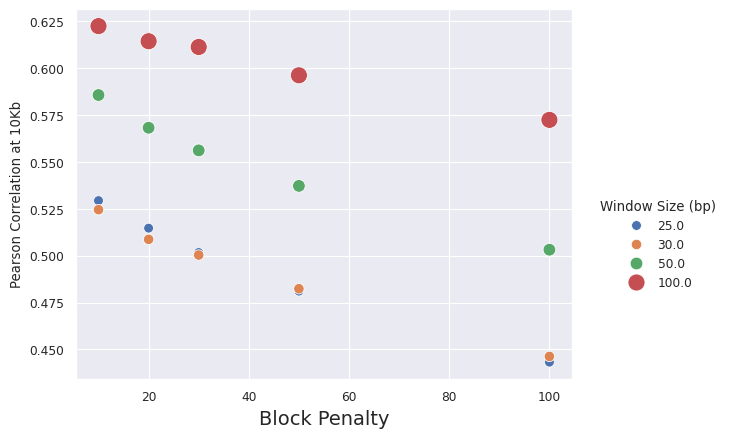

In [120]:
%matplotlib inline
from turtle import fillcolor, title


def plot_hyperparam(data_frame: pd.DataFrame) -> None:
    if data_frame.empty:
        print("DataFrame is empty.")
        return

    expected_cols = {"Block_Penalty", "Pearson_Corr_10kb", "Window_Size"}
    if not expected_cols.issubset(data_frame.columns):
        print(f"Missing columns: {expected_cols - set(data_frame.columns)}")
        print("Available columns:", list(data_frame.columns))
        return

    try:
        sns.set_style('darkgrid')
        ax = sns.scatterplot(
            data=data_frame,
            x="Block_Penalty",
            y="Pearson_Corr_10kb",
            size="Window_Size",
            hue="Window_Size",
            legend="auto",
            palette="deep",
            sizes=(50, 150)
        )
        
        handels, labels = ax.get_legend_handles_labels()
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        ax.legend(
            handles=handels,
            labels=labels,
            title="Window Size (bp)",
            bbox_to_anchor=(1.3, 0.5),
            loc='upper right',
            borderaxespad=0.0,
            frameon=False
        )
        plt.xlabel("Block Penalty", fontsize=14)
        plt.ylabel("Pearson Correlation at 10Kb")
        plt.show()
    except Exception as e:
        print(f"❌ Exception occurred while plotting: {e}")

plot_hyperparam(hyperparameters)